# Bootstrap pareado entre modelos

Qual a distribuição da diferença de AUPRC e de ROC-AUC entre pares de modelos, tomada réplica a réplica sobre as mesmas reamostragens do teste de 2024.
A comparação pareada responde o que os intervalos de confiança de cada modelo isolado não respondem: dois intervalos podem se sobrepor e ainda assim a diferença entre os modelos excluir o zero, porque a correlação entre eles é descartada quando se olha um de cada vez.
Lê as distribuições de bootstrap e as predições de `output/metricas_v2_calibradas/`, e a seleção de versões de `analysis/results_calibracao/selecao_base_vs_otimizada.csv`, pelo mesmo critério declarado nos notebooks 12 e 13.
Restringe-se aos modelos com calibração Platt no limiar de sensibilidade-alvo de 0,80; AUPRC e ROC-AUC não dependem do limiar, que aqui identifica o ponto de operação e não a métrica.
Nenhum modelo é treinado, calibrado ou selecionado.

## Etapas
1. Carregar as distribuições de bootstrap já gravadas e as predições dos 30 modelos com calibração Platt.
2. Conferir se as reamostragens gravadas são recuperáveis, recomputando três modelos com a mesma semente.
3. Calcular as estimativas pontuais no teste completo e ler a versão selecionada de cada algoritmo.
4. Definir a comparação pareada, com o par ordenado pela estimativa pontual.
5. Comparar todos os pares entre os cinco algoritmos na configuração final.
6. Comparar as configurações entre si, dentro de cada algoritmo e versão.
7. Comparar as versões base e otimizada, por algoritmo e configuração.
8. Gravar os histogramas da diferença de AUPRC entre algoritmos.

## Entradas
- `output/metricas_v2_calibradas/bootstrap_distribuicoes.parquet`
- `output/metricas_v2_calibradas/*_predicoes_platt.parquet`
- `analysis/results_calibracao/selecao_base_vs_otimizada.csv`

## Saídas
- `analysis/results_bootstrap_pareado/verificacao_reamostragens.csv`
- `analysis/results_bootstrap_pareado/versoes_do_item_1.csv`
- `analysis/results_bootstrap_pareado/comparacao_entre_algoritmos.csv`
- `analysis/results_bootstrap_pareado/comparacao_entre_configuracoes.csv`
- `analysis/results_bootstrap_pareado/comparacao_entre_versoes.csv`
- `analysis/plots/bootstrap_pareado/diferenca_auprc_entre_algoritmos.png`

Importações, caminhos, constantes e formatadores em português.

In [1]:
import os
import sys
import time
import textwrap
import itertools
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Raiz do repositorio por marcador estavel, e nao por contagem de niveis:
# reorganizar as pastas de notebooks deixa de quebrar os caminhos.
def _raiz_repo(inicio=None):
    d = os.path.abspath(inicio or os.getcwd())
    while not any(os.path.exists(os.path.join(d, m)) for m in ('pyproject.toml', '.git')):
        pai = os.path.dirname(d)
        if pai == d:
            raise RuntimeError(f'raiz do repositorio nao encontrada acima de {os.getcwd()}')
        d = pai
    return d

ROOT = _raiz_repo()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

DIR_CALIBRADAS = os.path.join(ROOT, 'output', 'metricas_v2_calibradas')
DIR_RES_CAL    = os.path.join(ROOT, 'analysis', 'results_calibracao')
DIR_TABELAS    = os.path.join(ROOT, 'analysis', 'results_bootstrap_pareado')
DIR_FIGURAS    = os.path.join(ROOT, 'analysis', 'plots', 'bootstrap_pareado')
for _d in (DIR_TABELAS, DIR_FIGURAS):
    os.makedirs(_d, exist_ok=True)

RANDOM_STATE = 42
N_BOOTSTRAP  = 2000
CALIBRACAO   = 'platt'
REGRA_LIMIAR = 'sensibilidade 0,80 no treino'

CONFIGS = ['antiga', 'corrigida', 'notificacao']
# Chave interna -> rotulo publicado. As chaves nomeiam arquivos e nao mudam.
ROTULO_CONFIG = {'antiga': 'original', 'corrigida': 'final',
                 'notificacao': 'sem critérios de gravidade'}
VERSOES = ['base', 'otimizada']
SUFIXO_VERSAO = {'base': '', 'otimizada': '_tuned'}
ALGORITMOS = {
    'logistic_regression': 'Regressão Logística',
    'decision_tree':       'Árvore de Decisão',
    'random_forest':       'Random Forest',
    'xgboost':             'XGBoost',
    'lightgbm':            'LightGBM',
}
METRICAS = ['auprc', 'roc_auc']
ROTULO_METRICA = {'auprc': 'AUPRC', 'roc_auc': 'ROC-AUC'}

COR_HIST = '#2a78d6'
COR_ZERO = '#52514e'

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.size': 9, 'axes.titlesize': 11, 'axes.labelsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c9c8c3', 'axes.labelcolor': '#52514e',
    'xtick.color': '#52514e', 'ytick.color': '#52514e', 'text.color': '#0b0b0b',
    'grid.color': '#e8e7e3', 'grid.linewidth': 0.8,
    'figure.facecolor': '#ffffff', 'axes.facecolor': '#ffffff', 'legend.frameon': False,
})


def n_(x):
    return f'{int(x):,}'.replace(',', '.')


def v_(x, casas=4):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return '—'
    return f'{x:.{casas}f}'.replace('.', ',')


def ic_(lo, hi, casas=4):
    return f'[{v_(lo, casas)}; {v_(hi, casas)}]'


def chave_de(algo, cfg, versao, calibracao=CALIBRACAO):
    return f'{algo}|{cfg}|{versao}|{calibracao}'


def rotulo_de(chave):
    algo, cfg, versao, _ = chave.split('|')
    return f'{ALGORITMOS[algo]} {versao} / {ROTULO_CONFIG[cfg]}'


def eixo_virgula(casas=2):
    return mpl.ticker.FuncFormatter(lambda x, pos=None: f'{x:.{casas}f}'.replace('.', ','))


def salvar_tab(df, nome, index=False):
    caminho = os.path.join(DIR_TABELAS, nome)
    df.to_csv(caminho, index=index, encoding='utf-8')
    print(f'[tabela] {os.path.relpath(caminho, ROOT)}  ({len(df)} linhas)')
    return df


def salvar_fig(fig, nome):
    caminho = os.path.join(DIR_FIGURAS, nome)
    fig.savefig(caminho, dpi=300, bbox_inches='tight', facecolor='#ffffff')
    print(f'[figura] {os.path.relpath(caminho, ROOT)}')


print(f'Calibração {CALIBRACAO} · limiar "{REGRA_LIMIAR}" · '
      f'{n_(N_BOOTSTRAP)} reamostragens · semente {RANDOM_STATE}')

Calibração platt · limiar "sensibilidade 0,80 no treino" · 2.000 reamostragens · semente 42


Carrega as distribuições de bootstrap já gravadas e as predições dos 30 modelos com calibração Platt.

In [2]:
CAMINHO_DIST = os.path.join(DIR_CALIBRADAS, 'bootstrap_distribuicoes.parquet')
df_dist = pd.read_parquet(CAMINHO_DIST)

CHAVES = [chave_de(a, c, v) for c in CONFIGS for a in ALGORITMOS for v in VERSOES]
faltando = [k for k in CHAVES if k not in set(df_dist['modelo'])]
assert not faltando, f'distribuições ausentes: {faltando}'

# As linhas de cada modelo estão na ordem das reamostragens: a linha b de todos os modelos
# veio do mesmo sorteio. É o que torna a comparação pareada.
dist = {k: df_dist[df_dist['modelo'] == k][METRICAS].reset_index(drop=True) for k in CHAVES}
for k in CHAVES:
    assert len(dist[k]) == N_BOOTSTRAP, f'{k}: {len(dist[k])} réplicas'

predicoes = {}
for k in CHAVES:
    algo, cfg, versao, met = k.split('|')
    arq = os.path.join(DIR_CALIBRADAS,
                       f'{algo}_{cfg}{SUFIXO_VERSAO[versao]}_predicoes_{met}.parquet')
    d = pd.read_parquet(arq)
    predicoes[k] = d['y_proba'].to_numpy()

Y_TESTE       = d['y_true'].to_numpy(dtype=int)
N_TESTE       = len(Y_TESTE)
EVENTOS_TESTE = int(Y_TESTE.sum())
print(f'{len(dist)} modelos Platt · {n_(N_TESTE)} internações, {n_(EVENTOS_TESTE)} óbitos no '
      f'teste de 2024')

30 modelos Platt · 160.302 internações, 5.292 óbitos no teste de 2024


Confere se as reamostragens gravadas são recuperáveis: recomputa as 2.000 réplicas de três modelos com a semente 42 e compara com o que está no arquivo.

In [3]:
def preparar(y, p):
    y = np.asarray(y, dtype=np.float64)
    p = np.asarray(p, dtype=np.float64)
    ordem = np.argsort(-p, kind='stable').astype(np.int32)
    p_ord = p[ordem]
    return {'ordem': ordem, 'y_ord': y[ordem],
            'corte': np.r_[np.flatnonzero(np.diff(p_ord)), len(p_ord) - 1]}


def metricas_pesadas(pre, w):
    w_ord = w[pre['ordem']]
    y_ord = pre['y_ord']
    vp = np.cumsum(w_ord * y_ord)[pre['corte']]
    fp = np.cumsum(w_ord * (1.0 - y_ord))[pre['corte']]
    n_pos, n_neg = max(vp[-1], 1e-12), max(fp[-1], 1e-12)
    precisao = vp / np.maximum(vp + fp, 1e-12)
    revocacao = vp / n_pos
    return {'auprc': float(np.sum(np.diff(np.r_[0.0, revocacao]) * precisao)),
            'roc_auc': float(np.trapezoid(np.r_[0.0, revocacao], np.r_[0.0, fp / n_neg]))}


CONFERIDOS = [chave_de('logistic_regression', 'antiga', 'base'),
              chave_de('random_forest', 'corrigida', 'otimizada'),
              chave_de('xgboost', 'notificacao', 'base')]

t0 = time.perf_counter()
pres = {k: preparar(Y_TESTE, predicoes[k]) for k in CONFERIDOS}
refeito = {k: np.empty((N_BOOTSTRAP, len(METRICAS))) for k in CONFERIDOS}
gerador = np.random.default_rng(RANDOM_STATE)
for b in range(N_BOOTSTRAP):
    w = np.bincount(gerador.integers(0, N_TESTE, N_TESTE), minlength=N_TESTE).astype(np.float64)
    for k in CONFERIDOS:
        m = metricas_pesadas(pres[k], w)
        refeito[k][b] = [m[nome] for nome in METRICAS]

linhas = []
for k in CONFERIDOS:
    linhas.append({
        'modelo': rotulo_de(k),
        'n_base_teste': N_TESTE, 'eventos_teste': EVENTOS_TESTE,
        'replicas': N_BOOTSTRAP,
        'delta_max_auprc': float(np.abs(refeito[k][:, 0] - dist[k]['auprc'].to_numpy()).max()),
        'delta_max_roc_auc': float(np.abs(refeito[k][:, 1] - dist[k]['roc_auc'].to_numpy()).max()),
    })
df_recuperacao = pd.DataFrame(linhas)
df_recuperacao['reamostragens'] = np.where(
    (df_recuperacao[['delta_max_auprc', 'delta_max_roc_auc']].max(axis=1) < 1e-12),
    'recuperadas dos artefatos', 'refeitas')
salvar_tab(df_recuperacao, 'verificacao_reamostragens.csv')
display(df_recuperacao)

RECUPERADAS = bool((df_recuperacao['reamostragens'] == 'recuperadas dos artefatos').all())
print(f'\nConferido em {time.perf_counter() - t0:.1f}s. '
      + ('As distribuições gravadas reproduzem exatamente o sorteio da semente 42, na mesma '
         'ordem de réplica: as reamostragens foram RECUPERADAS dos artefatos, não refeitas.'
         if RECUPERADAS else
         'As distribuições gravadas não reproduzem o sorteio: reamostragens REFEITAS.'))

[tabela] analysis/results_bootstrap_pareado/verificacao_reamostragens.csv  (3 linhas)


,modelo,n_base_teste,eventos_teste,replicas,delta_max_auprc,delta_max_roc_auc,reamostragens
0,Regressão Logística base / original,160302,5292,2000,0.0,0.0,recuperadas dos artefatos
1,Random Forest otimizada / final,160302,5292,2000,0.0,0.0,recuperadas dos artefatos
2,XGBoost base / sem critérios de gravidade,160302,5292,2000,0.0,0.0,recuperadas dos artefatos



Conferido em 19.1s. As distribuições gravadas reproduzem exatamente o sorteio da semente 42, na mesma ordem de réplica: as reamostragens foram RECUPERADAS dos artefatos, não refeitas.


Calcula as estimativas pontuais no teste completo e lê, para o item 1, a versão selecionada de cada algoritmo na configuração final. O critério é o declarado nos notebooks 12 e 13, maior AUPRC média na validação cruzada do treino, e a seleção vem do artefato, não é fixada aqui.

In [4]:
ponto = {k: metricas_pesadas(preparar(Y_TESTE, predicoes[k]), np.ones(N_TESTE)) for k in CHAVES}

# O critério é o mesmo dos notebooks 12 e 13: maior AUPRC média na validação cruzada do
# treino, com empate exato indo para a base por parcimônia. A seleção é derivada do
# artefato e nunca fixada aqui, para que os notebooks não possam divergir de novo.
df_sel = pd.read_csv(os.path.join(DIR_RES_CAL, 'selecao_base_vs_otimizada.csv'))
df_sel = df_sel[(df_sel['calibracao'] == 'Platt')
                & (df_sel['regra_limiar'] == REGRA_LIMIAR)
                & (df_sel['configuracao'] == ROTULO_CONFIG['corrigida'])]

# O limiar não seleciona nada: entra só para registrar o ponto de operação da versão escolhida.
df_lim = pd.read_csv(os.path.join(DIR_RES_CAL, 'limiares_teste_2024.csv'))
df_lim = df_lim[(df_lim['calibracao'] == 'Platt') & (df_lim['regra_limiar'] == REGRA_LIMIAR)
                & (df_lim['configuracao'] == ROTULO_CONFIG['corrigida'])]

versao_item1, linhas = {}, []
for algo, rotulo in ALGORITMOS.items():
    r = df_sel[df_sel['algoritmo'] == rotulo].iloc[0]
    base, otim = float(r['auprc_vc_treino_base']), float(r['auprc_vc_treino_otimizada'])
    versao = 'otimizada' if otim > base else 'base'
    versao_item1[algo] = versao
    limiar = df_lim[(df_lim['algoritmo'] == rotulo) & (df_lim['versao'] == versao)]['limiar']
    linhas.append({
        'algoritmo': rotulo, 'versao_escolhida': versao,
        'auprc_vc_treino_base': round(base, 4),
        'auprc_vc_treino_otimizada': round(otim, 4),
        'diferenca_auprc_vc_treino': round(otim - base, 4),
        'criterio': ('maior AUPRC na validação cruzada do treino' if otim != base
                     else 'empate exato, base por parcimônia'),
        'limiar': round(float(limiar.iloc[0]), 6),
        'auprc': round(ponto[chave_de(algo, 'corrigida', versao)]['auprc'], 4),
        'roc_auc': round(ponto[chave_de(algo, 'corrigida', versao)]['roc_auc'], 4),
        'n_base_teste': N_TESTE, 'eventos_teste': EVENTOS_TESTE,
    })

df_versoes = salvar_tab(pd.DataFrame(linhas), 'versoes_do_item_1.csv')
display(df_versoes)

# Trava contra divergência: se o notebook 12 já rodou, a seleção tem de bater linha a linha.
CAMINHO_SEL_12 = os.path.join(ROOT, 'analysis', 'results_equidade',
                              'selecao_versao_por_algoritmo.csv')
if os.path.exists(CAMINHO_SEL_12):
    sel12 = pd.read_csv(CAMINHO_SEL_12)
    sel12 = sel12[sel12['configuracao'] == ROTULO_CONFIG['corrigida']]
    inverso = {rot: a for a, rot in ALGORITMOS.items()}
    for _, r in sel12.iterrows():
        algo = inverso[r['algoritmo']]
        assert versao_item1[algo] == r['versao_selecionada'], (
            f'{r["algoritmo"]}: o item 1 usa {versao_item1[algo]} e o notebook 12 '
            f'seleciona {r["versao_selecionada"]}')
    print(f'\nSeleção conferida contra o notebook 12: as {len(sel12)} versões batem.')
else:
    print('\nNotebook 12 ainda não rodou: seleção não conferida contra ele.')

print(f'Versões otimizadas no item 1: '
      f'{sum(v == "otimizada" for v in versao_item1.values())} de {len(versao_item1)}')

[tabela] analysis/results_bootstrap_pareado/versoes_do_item_1.csv  (5 linhas)


,algoritmo,versao_escolhida,auprc_vc_treino_base,auprc_vc_treino_otimizada,diferenca_auprc_vc_treino,criterio,limiar,auprc,roc_auc,n_base_teste,eventos_teste
0,Regressão Logística,otimizada,0.6346,0.6347,0.0001,maior AUPRC na validação cruzada do treino,0.038431,0.6213,0.9259,160302,5292
1,Árvore de Decisão,otimizada,0.5730,0.6207,0.0477,maior AUPRC na validação cruzada do treino,0.019525,0.5827,0.9075,160302,5292
2,Random Forest,otimizada,0.6527,0.6530,0.0003,maior AUPRC na validação cruzada do treino,0.017056,0.6322,0.9195,160302,5292
3,XGBoost,otimizada,0.6298,0.6556,0.0258,maior AUPRC na validação cruzada do treino,0.038764,0.6447,0.9236,160302,5292
4,LightGBM,otimizada,0.6304,0.6477,0.0173,maior AUPRC na validação cruzada do treino,0.021941,0.6421,0.9206,160302,5292



Seleção conferida contra o notebook 12: as 5 versões batem.
Versões otimizadas no item 1: 5 de 5


Define a comparação pareada: a diferença é tomada réplica a réplica, e o par é ordenado para que o primeiro modelo seja o de maior estimativa pontual, de modo que a diferença relatada nunca seja negativa. Uma diferença é considerada distinguível de zero quando o intervalo de 95% da distribuição pareada não contém o zero.

In [5]:
def comparar(chave_a, chave_b, metrica):
    '''Diferença pareada sobre as mesmas reamostragens. O par é ordenado pela estimativa
    pontual, de modo que a diferença relatada nunca é negativa e o limite superior do
    intervalo lê como a maior vantagem plausível do primeiro sobre o segundo.'''
    if ponto[chave_a][metrica] < ponto[chave_b][metrica]:
        chave_a, chave_b = chave_b, chave_a
    va = dist[chave_a][metrica].to_numpy()
    vb = dist[chave_b][metrica].to_numpy()
    d = va - vb
    lo, hi = float(np.quantile(d, 0.025)), float(np.quantile(d, 0.975))
    ponto_d = float(ponto[chave_a][metrica] - ponto[chave_b][metrica])
    distinguivel = not (lo <= 0.0 <= hi)
    # Intervalos de cada modelo isolado, para pôr ao lado a leitura por sobreposição.
    ia = (float(np.quantile(va, 0.025)), float(np.quantile(va, 0.975)))
    ib = (float(np.quantile(vb, 0.025)), float(np.quantile(vb, 0.975)))
    sobrepoe = not (ia[1] < ib[0] or ib[1] < ia[0])
    # Tolerância, e não igualdade exata: dois ajustes independentes do mesmo calibrador
    # deixam ruído de ponto flutuante da ordem de 1e-16 em modelos que são o mesmo.
    identicas = bool(np.allclose(predicoes[chave_a], predicoes[chave_b], rtol=0, atol=1e-12))
    return {
        'modelo_a': rotulo_de(chave_a), 'modelo_b': rotulo_de(chave_b),
        'metrica': ROTULO_METRICA[metrica],
        'valor_a': round(ponto[chave_a][metrica], 4),
        'valor_b': round(ponto[chave_b][metrica], 4),
        'diferenca': round(ponto_d, 4),
        'ic_inf': round(lo, 4), 'ic_sup': round(hi, 4),
        'prop_a_supera_b': round(float(np.mean(va > vb)), 4),
        'prop_empate': round(float(np.mean(va == vb)), 4),
        'predicoes_identicas': 'sim' if identicas else 'não',
        'distinguivel_de_zero': 'sim' if distinguivel else 'não',
        'magnitude_pontual': round(abs(ponto_d), 4),
        'ic_individual_a': f'[{round(ia[0], 4)}; {round(ia[1], 4)}]',
        'ic_individual_b': f'[{round(ib[0], 4)}; {round(ib[1], 4)}]',
        'ics_individuais_sobrepoem': 'sim' if sobrepoe else 'não',
        'n_base_teste': N_TESTE, 'eventos_teste': EVENTOS_TESTE, 'replicas': N_BOOTSTRAP,
    }


print('Comparação pareada definida.')
print('Quando os dois modelos têm predições idênticas, a diferença é zero em toda réplica e a '
      'proporção de vitórias do primeiro sai zero: a coluna de predições idênticas sinaliza '
      'esses casos.')

Comparação pareada definida.
Quando os dois modelos têm predições idênticas, a diferença é zero em toda réplica e a proporção de vitórias do primeiro sai zero: a coluna de predições idênticas sinaliza esses casos.


Tabela 1 — todos os pares entre os cinco algoritmos na configuração final, com as três leituras lado a lado.

In [6]:
linhas = []
for metrica in METRICAS:
    for algo_a, algo_b in itertools.combinations(ALGORITMOS, 2):
        linhas.append(comparar(chave_de(algo_a, 'corrigida', versao_item1[algo_a]),
                               chave_de(algo_b, 'corrigida', versao_item1[algo_b]), metrica))

df_algoritmos = pd.DataFrame(linhas)
df_algoritmos.insert(0, 'comparacao',
                     f'entre algoritmos, configuração {ROTULO_CONFIG["corrigida"]}')
salvar_tab(df_algoritmos, 'comparacao_entre_algoritmos.csv')

vis = df_algoritmos[df_algoritmos['metrica'] == 'AUPRC'].copy()
vis['IC 95% da diferença'] = vis.apply(lambda r: ic_(r['ic_inf'], r['ic_sup']), axis=1)
display(vis[['modelo_a', 'modelo_b', 'diferenca', 'IC 95% da diferença', 'prop_a_supera_b',
             'distinguivel_de_zero']])
n_dist = int((vis['distinguivel_de_zero'] == 'sim').sum())
n_conflito = int(((vis['ics_individuais_sobrepoem'] == 'sim')
                  & (vis['distinguivel_de_zero'] == 'sim')).sum())
print(f'\nAUPRC: {n_dist} de {len(vis)} pares com diferença distinguível de zero.')
print(f'Em {n_conflito} de {len(vis)} pares os intervalos de cada modelo isolado se sobrepõem '
      f'e ainda assim a diferença pareada exclui o zero.')

# Os dez pares se separam em dois grupos de magnitude: os que envolvem a árvore de
# decisão e os demais, entre a regressão logística e os três ensembles.
ROTULO_ARVORE = ALGORITMOS['decision_tree']
TEM_ARVORE = (vis['modelo_a'].str.startswith(ROTULO_ARVORE)
              | vis['modelo_b'].str.startswith(ROTULO_ARVORE))
for rotulo_grupo, sel in (('entre a regressão logística e os três ensembles', ~TEM_ARVORE),
                          ('que envolvem a árvore de decisão', TEM_ARVORE)):
    g = vis.loc[sel, 'diferenca']
    print(f'Pares {rotulo_grupo}: {len(g)} pares, diferença de {v_(g.min())} a '
          f'{v_(g.max())}.')

[tabela] analysis/results_bootstrap_pareado/comparacao_entre_algoritmos.csv  (20 linhas)


,modelo_a,modelo_b,diferenca,IC 95% da diferença,prop_a_supera_b,distinguivel_de_zero
0,Regressão Logística otimizada / final,Árvore de Decisão otimizada / final,0.0386,"[0,0319; 0,0457]",1.0000,sim
1,Random Forest otimizada / final,Regressão Logística otimizada / final,0.0109,"[0,0055; 0,0161]",1.0000,sim
2,XGBoost otimizada / final,Regressão Logística otimizada / final,0.0234,"[0,0177; 0,0289]",1.0000,sim
3,LightGBM otimizada / final,Regressão Logística otimizada / final,0.0208,"[0,0151; 0,0267]",1.0000,sim
4,Random Forest otimizada / final,Árvore de Decisão otimizada / final,0.0495,"[0,0438; 0,0554]",1.0000,sim
5,XGBoost otimizada / final,Árvore de Decisão otimizada / final,0.0620,"[0,0576; 0,0664]",1.0000,sim
6,LightGBM otimizada / final,Árvore de Decisão otimizada / final,0.0595,"[0,0551; 0,0641]",1.0000,sim
7,XGBoost otimizada / final,Random Forest otimizada / final,0.0125,"[0,0089; 0,0160]",1.0000,sim
8,LightGBM otimizada / final,Random Forest otimizada / final,0.0099,"[0,0065; 0,0138]",1.0000,sim
9,XGBoost otimizada / final,LightGBM otimizada / final,0.0025,"[-0,0002; 0,0053]",0.9645,não



AUPRC: 9 de 10 pares com diferença distinguível de zero.
Em 5 de 10 pares os intervalos de cada modelo isolado se sobrepõem e ainda assim a diferença pareada exclui o zero.
Pares entre a regressão logística e os três ensembles: 6 pares, diferença de 0,0025 a 0,0234.
Pares que envolvem a árvore de decisão: 4 pares, diferença de 0,0386 a 0,0620.


Tabela 4 — todos os pares entre os cinco algoritmos na configuração sem critérios de gravidade.
Mesmo procedimento da Tabela 1, com a configuração trocada: versões lidas de `selecao_base_vs_otimizada.csv`, calibração Platt, as mesmas 2.000 reamostragens.
A seleção difere entre as duas configurações, e a diferença é registrada: sem os critérios de gravidade o Random Forest empata na validação cruzada e fica com a versão base, de modo que esse par não compara o mesmo modelo dos dois lados.

In [7]:
# A seleção da configuração sem critérios de gravidade é lida do mesmo artefato, pelo mesmo
# critério, e NÃO é herdada da configuração final: as duas podem divergir, e divergem.
df_sel_n = pd.read_csv(os.path.join(DIR_RES_CAL, 'selecao_base_vs_otimizada.csv'))
df_sel_n = df_sel_n[(df_sel_n['calibracao'] == 'Platt')
                    & (df_sel_n['regra_limiar'] == REGRA_LIMIAR)
                    & (df_sel_n['configuracao'] == ROTULO_CONFIG['notificacao'])]

versao_notificacao, linhas = {}, []
for algo, rotulo in ALGORITMOS.items():
    r = df_sel_n[df_sel_n['algoritmo'] == rotulo].iloc[0]
    base, otim = float(r['auprc_vc_treino_base']), float(r['auprc_vc_treino_otimizada'])
    versao_notificacao[algo] = 'otimizada' if otim > base else 'base'
    linhas.append({
        'algoritmo': rotulo,
        'versao_configuracao_final': versao_item1[algo],
        'versao_sem_criterios_gravidade': versao_notificacao[algo],
        'mesmo_modelo_nos_dois_lados': 'sim' if versao_item1[algo] == versao_notificacao[algo] else 'não',
        'auprc_vc_treino_base': round(base, 4),
        'auprc_vc_treino_otimizada': round(otim, 4),
        'criterio': ('maior AUPRC na validação cruzada do treino' if otim != base
                     else 'empate exato, base por parcimônia'),
    })
df_versoes_cfg = salvar_tab(pd.DataFrame(linhas), 'versoes_por_configuracao.csv')
display(df_versoes_cfg)

linhas = []
for metrica in METRICAS:
    for algo_a, algo_b in itertools.combinations(ALGORITMOS, 2):
        linhas.append(comparar(chave_de(algo_a, 'notificacao', versao_notificacao[algo_a]),
                               chave_de(algo_b, 'notificacao', versao_notificacao[algo_b]), metrica))

df_algoritmos_notif = pd.DataFrame(linhas)
df_algoritmos_notif.insert(0, 'comparacao',
                           f'entre algoritmos, configuração {ROTULO_CONFIG["notificacao"]}')
salvar_tab(df_algoritmos_notif, 'comparacao_entre_algoritmos_notificacao.csv')

vis_n = df_algoritmos_notif[df_algoritmos_notif['metrica'] == 'AUPRC'].copy()
vis_n['IC 95% da diferença'] = vis_n.apply(lambda r: ic_(r['ic_inf'], r['ic_sup']), axis=1)
display(vis_n[['modelo_a', 'modelo_b', 'diferenca', 'IC 95% da diferença', 'prop_a_supera_b',
               'distinguivel_de_zero']])
print(f"\nAUPRC: {int((vis_n['distinguivel_de_zero'] == 'sim').sum())} de {len(vis_n)} pares "
      f'com diferença distinguível de zero.')

# A leitura que motiva este bloco: a vantagem dos ensembles sobre a regressão logística nas duas
# configurações, em valor absoluto e como fração da AUPRC dela na MESMA configuração. A fração é
# necessária porque a AUPRC absoluta cai de cerca de 0,62 para cerca de 0,28 entre as duas.
ROT_LR = ALGORITMOS['logistic_regression']
auprc_lr = {c: ponto[chave_de('logistic_regression', c, v[('logistic_regression')])]['auprc']
            for c, v in (('corrigida', versao_item1), ('notificacao', versao_notificacao))}

def vantagem(df, cfg, algo):
    rot = ALGORITMOS[algo]
    d = df[(df['metrica'] == 'AUPRC')
           & (df['modelo_a'].str.startswith((rot, ROT_LR)))
           & (df['modelo_b'].str.startswith((rot, ROT_LR)))].iloc[0]
    sinal = 1.0 if d['modelo_a'].startswith(rot) else -1.0
    return sinal * d['diferenca'], d['ic_inf'], d['ic_sup'], d['distinguivel_de_zero']

linhas = []
for algo in ('xgboost', 'lightgbm', 'random_forest'):
    for cfg, df_cfg in (('corrigida', df_algoritmos), ('notificacao', df_algoritmos_notif)):
        dif, lo, hi, dist_ = vantagem(df_cfg, cfg, algo)
        linhas.append({
            'ensemble': ALGORITMOS[algo], 'configuracao': ROTULO_CONFIG[cfg],
            'auprc_regressao_logistica': round(auprc_lr[cfg], 4),
            'vantagem_absoluta': round(dif, 4), 'ic_inf': lo, 'ic_sup': hi,
            'vantagem_relativa_pct': round(100 * dif / auprc_lr[cfg], 1),
            'distinguivel_de_zero': dist_,
        })
df_vantagem = salvar_tab(pd.DataFrame(linhas), 'vantagem_ensembles_sobre_lr_por_configuracao.csv')
display(df_vantagem)

# Ranqueamento e inversões de ordenação entre as duas configurações.
def ranque(cfg, versoes):
    v = sorted(((ponto[chave_de(a, cfg, versoes[a])]['auprc'], a) for a in ALGORITMOS), reverse=True)
    return [a for _, a in v]
r_corr, r_notif = ranque('corrigida', versao_item1), ranque('notificacao', versao_notificacao)
print(f"\nRanqueamento por AUPRC na configuração final:  "
      + ' > '.join(ALGORITMOS[a] for a in r_corr))
print(f"Ranqueamento na sem critérios de gravidade:     "
      + ' > '.join(ALGORITMOS[a] for a in r_notif))
print(f"Logistic Regression: {r_corr.index('logistic_regression') + 1}º na final, "
      f"{r_notif.index('logistic_regression') + 1}º na sem critérios de gravidade.")

pos_c = {a: i for i, a in enumerate(r_corr)}
pos_n = {a: i for i, a in enumerate(r_notif)}
invertidos = [(a, b) for a, b in itertools.combinations(ALGORITMOS, 2)
              if (pos_c[a] < pos_c[b]) != (pos_n[a] < pos_n[b])]
print(f"\nPares que invertem a ordenação entre as duas configurações: {len(invertidos)} de 10")
for a, b in invertidos:
    print(f"  {ALGORITMOS[a]} e {ALGORITMOS[b]}")

[tabela] analysis/results_bootstrap_pareado/versoes_por_configuracao.csv  (5 linhas)


,algoritmo,versao_configuracao_final,versao_sem_criterios_gravidade,mesmo_modelo_nos_dois_lados,auprc_vc_treino_base,auprc_vc_treino_otimizada,criterio
0,Regressão Logística,otimizada,otimizada,sim,0.2772,0.2819,maior AUPRC na validação cruzada do treino
1,Árvore de Decisão,otimizada,otimizada,sim,0.2066,0.2144,maior AUPRC na validação cruzada do treino
2,Random Forest,otimizada,base,não,0.2755,0.2755,"empate exato, base por parcimônia"
3,XGBoost,otimizada,otimizada,sim,0.2556,0.2982,maior AUPRC na validação cruzada do treino
4,LightGBM,otimizada,otimizada,sim,0.2583,0.2926,maior AUPRC na validação cruzada do treino


[tabela] analysis/results_bootstrap_pareado/comparacao_entre_algoritmos_notificacao.csv  (20 linhas)


,modelo_a,modelo_b,diferenca,IC 95% da diferença,prop_a_supera_b,distinguivel_de_zero
0,Regressão Logística otimizada / sem critérios ...,Árvore de Decisão otimizada / sem critérios de...,0.0552,"[0,0471; 0,0635]",1.0000,sim
1,Regressão Logística otimizada / sem critérios ...,Random Forest base / sem critérios de gravidade,0.0068,"[0,0011; 0,0127]",0.9875,sim
2,XGBoost otimizada / sem critérios de gravidade,Regressão Logística otimizada / sem critérios ...,0.0084,"[0,0029; 0,0141]",0.9980,sim
3,LightGBM otimizada / sem critérios de gravidade,Regressão Logística otimizada / sem critérios ...,0.0085,"[0,0036; 0,0135]",0.9995,sim
4,Random Forest base / sem critérios de gravidade,Árvore de Decisão otimizada / sem critérios de...,0.0485,"[0,0401; 0,0566]",1.0000,sim
5,XGBoost otimizada / sem critérios de gravidade,Árvore de Decisão otimizada / sem critérios de...,0.0636,"[0,0552; 0,0730]",1.0000,sim
6,LightGBM otimizada / sem critérios de gravidade,Árvore de Decisão otimizada / sem critérios de...,0.0638,"[0,0559; 0,0717]",1.0000,sim
7,XGBoost otimizada / sem critérios de gravidade,Random Forest base / sem critérios de gravidade,0.0151,"[0,0090; 0,0215]",1.0000,sim
8,LightGBM otimizada / sem critérios de gravidade,Random Forest base / sem critérios de gravidade,0.0153,"[0,0094; 0,0212]",1.0000,sim
9,LightGBM otimizada / sem critérios de gravidade,XGBoost otimizada / sem critérios de gravidade,0.0002,"[-0,0046; 0,0052]",0.5120,não



AUPRC: 9 de 10 pares com diferença distinguível de zero.
[tabela] analysis/results_bootstrap_pareado/vantagem_ensembles_sobre_lr_por_configuracao.csv  (6 linhas)


,ensemble,configuracao,auprc_regressao_logistica,vantagem_absoluta,ic_inf,ic_sup,vantagem_relativa_pct,distinguivel_de_zero
0,XGBoost,final,0.6213,0.0234,0.0177,0.0289,3.8,sim
1,XGBoost,sem critérios de gravidade,0.2816,0.0084,0.0029,0.0141,3.0,sim
2,LightGBM,final,0.6213,0.0208,0.0151,0.0267,3.3,sim
3,LightGBM,sem critérios de gravidade,0.2816,0.0085,0.0036,0.0135,3.0,sim
4,Random Forest,final,0.6213,0.0109,0.0055,0.0161,1.8,sim
5,Random Forest,sem critérios de gravidade,0.2816,-0.0068,0.0011,0.0127,-2.4,sim



Ranqueamento por AUPRC na configuração final:  XGBoost > LightGBM > Random Forest > Regressão Logística > Árvore de Decisão
Ranqueamento na sem critérios de gravidade:     LightGBM > XGBoost > Regressão Logística > Random Forest > Árvore de Decisão
Logistic Regression: 4º na final, 3º na sem critérios de gravidade.

Pares que invertem a ordenação entre as duas configurações: 2 de 10
  Regressão Logística e Random Forest
  XGBoost e LightGBM


Tabela 2 — original contra final e final contra sem critérios de gravidade, dentro de cada algoritmo, nas duas versões.

In [8]:
PARES_CONFIG = [('antiga', 'corrigida'), ('corrigida', 'notificacao')]

linhas = []
for metrica in METRICAS:
    for algo in ALGORITMOS:
        for versao in VERSOES:
            for cfg_a, cfg_b in PARES_CONFIG:
                r = comparar(chave_de(algo, cfg_a, versao),
                             chave_de(algo, cfg_b, versao), metrica)
                r.update({'algoritmo': ALGORITMOS[algo], 'versao': versao,
                          'par_de_configuracoes': f'{ROTULO_CONFIG[cfg_a]} × '
                                                  f'{ROTULO_CONFIG[cfg_b]}'})
                linhas.append(r)

df_configuracoes = pd.DataFrame(linhas)
df_configuracoes.insert(0, 'comparacao', 'entre configurações, dentro do algoritmo')
colunas = (['comparacao', 'algoritmo', 'versao', 'par_de_configuracoes']
           + [c for c in df_configuracoes.columns
              if c not in ('comparacao', 'algoritmo', 'versao', 'par_de_configuracoes')])
df_configuracoes = df_configuracoes[colunas]
salvar_tab(df_configuracoes, 'comparacao_entre_configuracoes.csv')

vis = df_configuracoes[df_configuracoes['metrica'] == 'AUPRC']
display(vis[['algoritmo', 'versao', 'par_de_configuracoes', 'modelo_a', 'diferenca',
             'ic_inf', 'ic_sup', 'prop_a_supera_b', 'distinguivel_de_zero']].head(12))
print(f'\nAUPRC: {int((vis["distinguivel_de_zero"] == "sim").sum())} de {len(vis)} pares de '
      f'configuração com diferença distinguível de zero.')

[tabela] analysis/results_bootstrap_pareado/comparacao_entre_configuracoes.csv  (40 linhas)


,algoritmo,versao,par_de_configuracoes,modelo_a,diferenca,ic_inf,ic_sup,prop_a_supera_b,distinguivel_de_zero
0,Regressão Logística,base,original × final,Regressão Logística base / original,0.0045,-0.0001,0.0093,0.9740,não
1,Regressão Logística,base,final × sem critérios de gravidade,Regressão Logística base / final,0.3411,0.3290,0.3530,1.0000,sim
2,Regressão Logística,otimizada,original × final,Regressão Logística otimizada / original,0.0044,-0.0002,0.0093,0.9705,não
3,Regressão Logística,otimizada,final × sem critérios de gravidade,Regressão Logística otimizada / final,0.3397,0.3275,0.3516,1.0000,sim
4,Árvore de Decisão,base,original × final,Árvore de Decisão base / final,0.0314,0.0230,0.0403,1.0000,sim
5,Árvore de Decisão,base,final × sem critérios de gravidade,Árvore de Decisão base / final,0.3591,0.3441,0.3734,1.0000,sim
6,Árvore de Decisão,otimizada,original × final,Árvore de Decisão otimizada / final,0.0225,0.0140,0.0308,1.0000,sim
7,Árvore de Decisão,otimizada,final × sem critérios de gravidade,Árvore de Decisão otimizada / final,0.3563,0.3418,0.3699,1.0000,sim
8,Random Forest,base,original × final,Random Forest base / final,0.0058,0.0023,0.0091,1.0000,sim
9,Random Forest,base,final × sem critérios de gravidade,Random Forest base / final,0.3581,0.3440,0.3711,1.0000,sim



AUPRC: 18 de 20 pares de configuração com diferença distinguível de zero.


Tabela 3 — versão base contra otimizada, por algoritmo e configuração.

In [9]:
linhas = []
for metrica in METRICAS:
    for algo in ALGORITMOS:
        for cfg in CONFIGS:
            r = comparar(chave_de(algo, cfg, 'base'), chave_de(algo, cfg, 'otimizada'), metrica)
            r.update({'algoritmo': ALGORITMOS[algo], 'configuracao': ROTULO_CONFIG[cfg]})
            linhas.append(r)

df_versoes_par = pd.DataFrame(linhas)
df_versoes_par.insert(0, 'comparacao', 'entre versões, dentro do algoritmo e da configuração')
colunas = (['comparacao', 'algoritmo', 'configuracao']
           + [c for c in df_versoes_par.columns
              if c not in ('comparacao', 'algoritmo', 'configuracao')])
df_versoes_par = df_versoes_par[colunas]
salvar_tab(df_versoes_par, 'comparacao_entre_versoes.csv')

vis = df_versoes_par[df_versoes_par['metrica'] == 'AUPRC']
display(vis[['algoritmo', 'configuracao', 'modelo_a', 'diferenca', 'ic_inf', 'ic_sup',
             'prop_a_supera_b', 'distinguivel_de_zero']])
print(f'\nAUPRC: {int((vis["distinguivel_de_zero"] == "sim").sum())} de {len(vis)} pares de '
      f'versão com diferença distinguível de zero.')

[tabela] analysis/results_bootstrap_pareado/comparacao_entre_versoes.csv  (30 linhas)


,algoritmo,configuracao,modelo_a,diferenca,ic_inf,ic_sup,prop_a_supera_b,distinguivel_de_zero
0,Regressão Logística,original,Regressão Logística otimizada / original,0.0001,-0.0002,0.0003,0.7065,não
1,Regressão Logística,final,Regressão Logística otimizada / final,0.0001,-0.0000,0.0003,0.9650,não
2,Regressão Logística,sem critérios de gravidade,Regressão Logística otimizada / sem critérios ...,0.0016,0.0002,0.0028,0.9890,sim
3,Árvore de Decisão,original,Árvore de Decisão otimizada / original,0.0096,0.0014,0.0179,0.9870,sim
4,Árvore de Decisão,final,Árvore de Decisão otimizada / final,0.0007,-0.0064,0.0075,0.5645,não
5,Árvore de Decisão,sem critérios de gravidade,Árvore de Decisão otimizada / sem critérios de...,0.0035,-0.0034,0.0102,0.8435,não
6,Random Forest,original,Random Forest base / original,0.0001,-0.0029,0.0032,0.5225,não
7,Random Forest,final,Random Forest base / final,0.0008,-0.0010,0.0025,0.7895,não
8,Random Forest,sem critérios de gravidade,Random Forest base / sem critérios de gravidade,0.0000,0.0000,0.0000,0.0000,não
9,XGBoost,original,XGBoost otimizada / original,0.0182,0.0129,0.0231,1.0000,sim



AUPRC: 8 de 15 pares de versão com diferença distinguível de zero.


Histogramas da diferença de AUPRC dos dez pares entre algoritmos, com o zero marcado.

[figura] analysis/plots/bootstrap_pareado/diferenca_auprc_entre_algoritmos.png


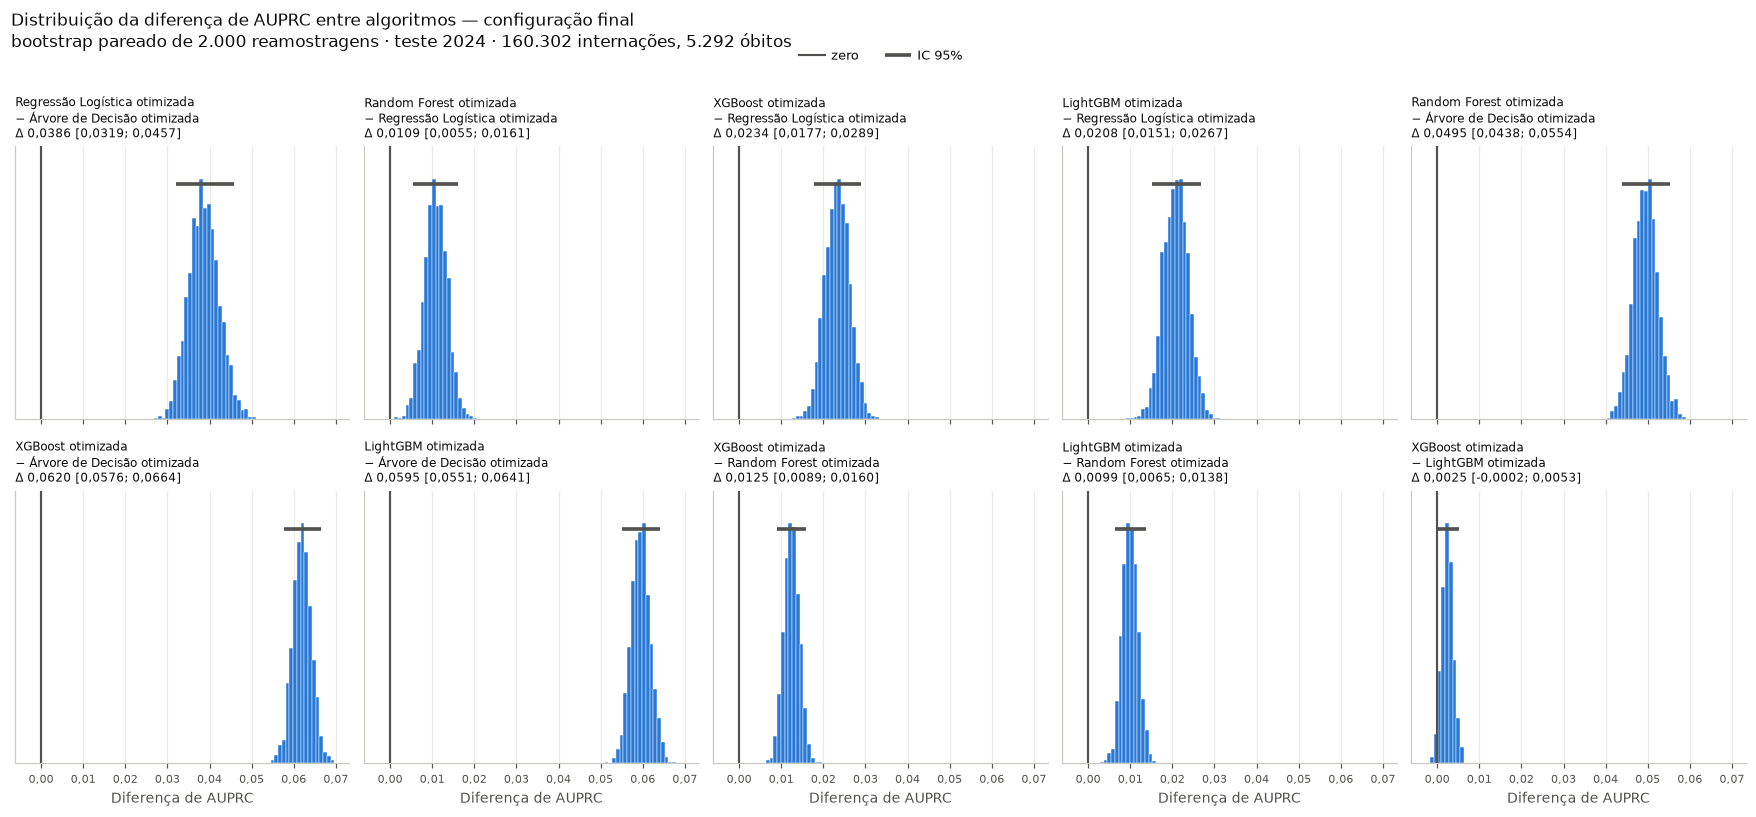

In [10]:
pares = [(a, b) for a, b in itertools.combinations(ALGORITMOS, 2)]

# Uma escala só para os dez painéis: com escalas próprias não daria para comparar as
# magnitudes de relance.
curvas = {}
for algo_a, algo_b in pares:
    ka = chave_de(algo_a, 'corrigida', versao_item1[algo_a])
    kb = chave_de(algo_b, 'corrigida', versao_item1[algo_b])
    if ponto[ka]['auprc'] < ponto[kb]['auprc']:
        ka, kb = kb, ka
    curvas[(algo_a, algo_b)] = (ka, kb,
                                dist[ka]['auprc'].to_numpy() - dist[kb]['auprc'].to_numpy())

todas = np.concatenate([d for _, _, d in curvas.values()])
folga = 0.06 * (todas.max() - todas.min())
# O zero entra na faixa mesmo que nenhuma réplica o alcance: é a referência dos painéis.
faixa = (min(todas.min(), 0.0) - folga, max(todas.max(), 0.0) + folga)
bordas = np.linspace(faixa[0], faixa[1], 90)

fig, axes = plt.subplots(2, 5, figsize=(16.0, 7.4), sharex=True)
for ax, chave_par in zip(axes.ravel(), pares):
    ka, kb, d = curvas[chave_par]
    lo, hi = np.quantile(d, [0.025, 0.975])

    ax.hist(d, bins=bordas, color=COR_HIST, edgecolor='#ffffff', linewidth=0.3, zorder=3)
    ax.axvline(0, color=COR_ZERO, linewidth=1.4, zorder=4, label='zero')
    topo = ax.get_ylim()[1]
    ax.plot([lo, hi], [topo * 0.93] * 2, color=COR_ZERO, linewidth=2.4, zorder=5,
            solid_capstyle='butt', label='IC 95%')
    ax.set_ylim(0, topo * 1.08)

    # Δ e intervalo vão no título: dentro do painel esbarrariam na barra do IC.
    ax.set_title(f'{rotulo_de(ka).split(" /")[0]}\n− {rotulo_de(kb).split(" /")[0]}\n'
                 f'Δ {v_(float(ponto[ka]["auprc"] - ponto[kb]["auprc"]))} {ic_(lo, hi)}',
                 loc='left', fontsize=8)
    ax.set_yticks([])
    ax.grid(True, axis='x', alpha=0.9, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(axis='x', labelsize=7.5)

axes[0, 0].set_xlim(*faixa)
for ax in axes[1]:
    ax.set_xlabel('Diferença de AUPRC')
    ax.xaxis.set_major_formatter(eixo_virgula(2))

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.tight_layout(rect=(0, 0, 1, 0.91))
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.963), ncol=2,
           fontsize=8.5, handletextpad=0.5, columnspacing=2.0)
fig.suptitle(f'Distribuição da diferença de AUPRC entre algoritmos — '
             f'configuração {ROTULO_CONFIG["corrigida"]}\n'
             f'bootstrap pareado de {n_(N_BOOTSTRAP)} reamostragens · teste 2024 · '
             f'{n_(N_TESTE)} internações, {n_(EVENTOS_TESTE)} óbitos',
             x=0.006, y=0.995, ha='left', va='top', fontsize=11)
salvar_fig(fig, 'diferenca_auprc_entre_algoritmos.png')
plt.show()

## Conclusões

- Uma diferença é considerada distinguível de zero quando o intervalo de 95% da distribuição
  pareada não contém o zero, e as magnitudes são reportadas como observadas, sem teste formal
  de não inferioridade.
  Nenhuma das leituras abaixo afirma equivalência entre modelos.

- As reamostragens foram recuperadas dos artefatos, não refeitas.
  A recomputação de três modelos com a semente 42 devolve as 2.000 réplicas com diferença máxima
  nula em AUPRC e em ROC-AUC, o que confirma que a linha de índice b de todos os modelos veio do
  mesmo sorteio.

- A seleção de versões do item 1 passou a ser lida de `selecao_base_vs_otimizada.csv`, pelo
  critério declarado nos notebooks 12 e 13: maior AUPRC média na validação cruzada do treino, com
  empate exato indo para a base.
  Na configuração final o critério escolhe a versão otimizada nos cinco algoritmos, e a
  conferência contra a seleção do notebook 12 bate nas cinco linhas.
  A execução anterior comparava Logistic Regression, XGBoost e LightGBM na versão base contra
  Random Forest e Decision Tree na otimizada, porque escolhia pela maior sensibilidade medida
  no teste de 2024, e não pelo critério declarado.

- Entre os cinco algoritmos na configuração final, 9 dos 10 pares têm diferença de AUPRC
  distinguível de zero, e 9 dos 10 em ROC-AUC.

- Em 5 dos 10 pares os intervalos de cada modelo isolado se sobrepõem e, ainda assim, a diferença
  pareada exclui o zero.
  São todos os pares entre a Logistic Regression e os três ensembles, mais XGBoost contra Random
  Forest e LightGBM contra Random Forest.

- O único par sem diferença distinguível em AUPRC é XGBoost contra LightGBM, 0,0025
  [-0,0002; 0,0053], com o primeiro superando o segundo em 96,5% das reamostragens.
  Em ROC-AUC o único é LightGBM contra Random Forest, 0,0011 [-0,0008; 0,0030].

- As duas faixas de magnitude não se sobrepõem em nenhuma das duas métricas.
  Em AUPRC, os quatro pares que envolvem a Decision Tree vão de 0,0386 a 0,0620 e os seis
  demais de 0,0025 a 0,0234.
  Em ROC-AUC, de 0,0119 a 0,0184 contra 0,0011 a 0,0064.

- A maior diferença entre algoritmos é de 0,0620 [0,0576; 0,0664], do XGBoost sobre a árvore de
  decisão.

- A Logistic Regression fica em quarto lugar entre os cinco no AUPRC, com 0,6213, atrás de
  XGBoost, LightGBM e Random Forest, e os três a superam com diferença distinguível de zero.
  Em ROC-AUC ela fica em primeiro, com 0,9259, e supera os três ensembles também com diferença
  distinguível de zero.
  As duas métricas ordenam os modelos de maneira oposta, e o AUPRC é o que pesa a classe rara.

- Entre as configurações original e final, 18 dos 20 pares têm diferença de AUPRC distinguível
  de zero.
  Os dois restantes são os da Logistic Regression, onde a original está acima por 0,0045 e 0,0044,
  com intervalos [-0,0001; 0,0093] e [-0,0002; 0,0093] que contêm o zero.

- Entre a final e a sem critérios de gravidade, os 10 pares têm diferença distinguível de zero, com magnitudes
  de 0,3397 a 0,3591, uma ordem de grandeza acima de tudo o mais medido aqui.

- Entre as versões base e otimizada, 8 dos 15 pares têm diferença de AUPRC distinguível de zero e
  13 dos 15 em ROC-AUC.

- O par de versões com predições idênticas é o Random Forest da configuração sem critérios de gravidade, com
  diferença zero em todas as 2.000 réplicas e intervalo [0,0000; 0,0000].
- **Bloco entre algoritmos na configuração sem critérios de gravidade.**
  Mesmo procedimento do bloco da configuração final, com a configuração trocada.
  Também aqui 9 dos 10 pares têm diferença de AUPRC distinguível de zero, e 9 dos 10 em ROC-AUC;
  o par indistinguível em AUPRC é LightGBM contra XGBoost, 0,0002 [-0,0046; 0,0052].

- A seleção de versões **difere entre as duas configurações**, e a diferença está registrada em
  `versoes_por_configuracao.csv`.
  Na final o critério escolhe a otimizada nos cinco algoritmos; sem os critérios de gravidade ele
  escolhe a otimizada em quatro e a **base no Random Forest**, por empate exato na validação
  cruzada do treino (0,2755 nas duas versões).
  O par que envolve o Random Forest, portanto, não compara o mesmo modelo dos dois lados, e a
  ressalva acompanha qualquer leitura desse par.

- **A hipótese que motivou este bloco não se confirma.**
  A vantagem absoluta dos ensembles sobre a Logistic Regression cai de 0,0234 para 0,0084 no
  XGBoost, de 0,0208 para 0,0085 no LightGBM, e inverte-se no Random Forest, que passa de
  superar por 0,0109 a ser superado por 0,0068 [0,0011; 0,0127].
  Em proporção da AUPRC da Logistic Regression na mesma configuração, contudo, a vantagem
  permanece da mesma ordem: 3,8% para 3,0% no XGBoost e 3,3% para 3,0% no LightGBM.
  A redução absoluta acompanha a queda geral de desempenho no regime sem informação posterior à
  notificação, e não autoriza atribuir a vantagem dos ensembles ao bloco de critérios de gravidade.
  A inversão do Random Forest é o único caso de mudança de sinal, e é justamente aquele em que os
  dois lados não são o mesmo modelo.

- **Duas ordenações se invertem** entre as configurações: Random Forest contra Logistic Regression
  e XGBoost contra LightGBM.
  A Logistic Regression sobe de 4ª de 5 na configuração final para 3ª de 5 na sem critérios de
  gravidade.
  Os outros oito pares mantêm a ordenação.
